<a href="https://colab.research.google.com/github/Gcostasilva/Python/blob/main/olist_e_comerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise E-Comerce Brasil Olist

Dados de transações comerciais entre 2016 e 2018.
Dados anonimizados utilizando hash.


## Entendimento do Negócio

    
**Análises de Vendas e Performance**

    Qual o faturamento total e evolução temporal das vendas?
    Quais os meses/períodos com maior volume de vendas?
    Qual o ticket médio dos pedidos?
    Qual a taxa de crescimento das vendas ao longo do período?
    Qual a distribuição de vendas por categoria de produto?

**Análises de Satisfação**

    Qual a nota média de satisfação dos clientes?
    Quais fatores mais impactam a avaliação (prazo, produto, atendimento)?
    Quais produtos estão mais propensos a avaliações negativas?
    Qual a distribuição das notas (1-5 estrelas)?
    Existe correlação entre atraso na entrega e avaliações negativas?

**Análises de Pagamento**

    Quais as formas de pagamento mais utilizadas?
    Qual o valor médio por tipo de pagamento?
    Existe relação entre método de pagamento e ticket médio?

**Análises de Logística e Entrega**

    Qual o prazo médio de entrega?
    Percentual de entregas no prazo vs atrasadas?

**Análises de Produtos**

    Quais categorias de produtos mais vendidas?
    Produtos com melhores avaliações?

**Análises de Vendedores**

    Quantidade e performance dos vendedores?
    Concentração de vendas (poucos vendem muito)?
    Relação entre localização do vendedor e performance?

**Análises Preditivas e ML**

    Previsão de demanda por categoria/período
    Predição de satisfação do cliente
    Classificação de risco de review negativa
    Previsão de churn de clientes
    Sistemas de recomendação

Entendimento do negócio:

Empresa no ramo de e-commerce atua na modalidade B2B2BC conectando logistas a clientes. Tem como principal característica a centralização dos pedidos, logo, seu público alvo são os vendedores parceiros.

A empresa agrega os pedidos de diferentes plataformas(Mercado Livre, Americanas, Magazine Luiza entre outras) em uma só plataforma, onde cada vendedor tem um painel único, com os pedidos que devem ser embalados e despachados.


Objetivo de Negócio:

Melhorar o desempenho comercial e a satisfação do cliente, orientando decisões baseadas em dados.

Tais perguntas devem ser respondidas:
Como anda as vendas;

*   List item
*   List item


Quais estados vendem mais;

*   List item
*   List item


Onde está a maior concentração de seus clientes;
Quais fatores mais impactam nas avaliações negativas;
Quais categorias de produtos vendem melhor;
Produtos com maior taxa de avaliações negativas entre outras.


Objetivo de Mineração de Dados:

Realizar uma análise exploratória e preditiva sobre:

 Vendas;
Localização dos clientes;
Categorias de produtos;
Fatores que influenciam as avaliações.


Será considerado um sucesso se as seguintes características forem atendidas:

Aumentar em 5% a captação de novos usuários(Tendo em vista ações de marketing melhor direcionadas)
Melhorar a avaliação média dos pedidos em, no mínimo, 0,2 pontos


Responsáveis e cronograma

A análise será conduzida por Guilherme da Silva Costa, com orientação do Prof Bruno Martins Bartolomeu.

Espera-se que a análise seja concluída até o fim de novembro(29/11/2025). Será utilizado a linguagem python e suas bibliotecas.



## Entendimento dos dados

### Importação

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
"""
!pip install -q plotly scikit-learn wordcloud
"""
import pandas as pd                     # Análise e alteração do DF
import numpy as np                      # Calculos
import matplotlib.pyplot as plt         # Visualização
import seaborn as sns                   # Visualização
import re                               #
import warnings                         # Remover os avisos
import plotly.express as px             # Visualização interativa
import requests                         #
import plotly.graph_objects as go       # Visualização interativa

from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Origem https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
pasta = 'drive/MyDrive/Colab Notebooks/'
costumer = pd.read_csv(pasta + 'olist_customers_dataset.csv')
#local = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv(pasta + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(pasta + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(pasta + 'olist_order_reviews_dataset.csv')
orders = pd.read_csv(pasta + 'olist_orders_dataset.csv')
products = pd.read_csv(pasta + 'olist_products_dataset.csv')
sellers = pd.read_csv(pasta + 'olist_sellers_dataset.csv')
#category_name_translation = pd.read_csv('product_category_name_translation.csv')



In [3]:
def visualiza_df(df):
    '''
        Exibe informações básicas do DataFrame que está sendo observado
    '''
    #Formato do DF
    print('\033[31m Formato:\033[0m')
    print(f'{df.shape[0] :,} linhas e {df.shape[1]} colunas.')

    # Valores ausentes
    print(f'{'=' * 50}')
    print('\033[31m Valores ausentes:\033[0m')
    print(df.isnull().sum())

    # Duplicatas
    print(f'{'=' * 50}')
    print('\033[31m Duplicatas: \033[0m')
    print(df.duplicated().sum())

    # Tipos de dados
    print(f'{'=' * 50}')
    print('\033[31m Tipos de dados: \033[0m')
    print(df.dtypes)

    # Visualização dados brutos
    print(f'{'=' * 50}')
    print('\033[31m Pré-visualização dos dados: \033[0m')
    df.head(5)

    return df

## Preparação dos dados

### Alteração tipo de dados

In [4]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])


### Limpeza das colunas

In [5]:
products = products.drop(columns={'product_description_lenght', 'product_photos_qty', 'product_name_lenght', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'}, axis=1)
order_reviews = order_reviews.drop(columns= {'review_comment_title', 'review_answer_timestamp', 'review_creation_date'}, axis=1)
orders = orders.drop(columns={'order_approved_at', 'order_delivered_carrier_date'}, axis=1)
orders= orders[orders['order_status'] == 'delivered']
order_payments = order_payments.drop(columns={'payment_sequential', 'payment_installments', 'payment_value'}, axis=1)
costumer = costumer.drop(columns={'customer_zip_code_prefix'}, axis=1)
sellers = sellers.drop(columns={'seller_zip_code_prefix'}, axis=1)

# Tem ainda produtos sem a categoria, são 610 itens, que, ao mesclar com os orders_items se torna 1603 itens, posteriormente será exluido do dataset

### Renomear Colunas

In [6]:
orders = orders.rename(columns={'order_purchase_timestamp': 'order_date'})

### Integrando os datasets

In [7]:
df = orders \
    .merge(order_items, on='order_id', how='left') \
    .merge(products, on='product_id', how='left') \
    .merge(sellers, on='seller_id', how='left') \
    .merge(costumer, on='customer_id', how='left') \
    .merge(order_payments, on='order_id', how='left') \
    .merge(order_reviews, on='order_id', how='left')

visualiza_df(df)

 Formato:
115,723 linhas e 22 colunas.
 Valores ausentes:
order_id                             0
customer_id                          0
order_status                         0
order_date                           0
order_delivered_customer_date        8
order_estimated_delivery_date        0
order_item_id                        0
product_id                           0
seller_id                            0
shipping_limit_date                  0
price                                0
freight_value                        0
product_category_name             1638
seller_city                          0
seller_state                         0
customer_unique_id                   0
customer_city                        0
customer_state                       0
payment_type                         3
review_id                          861
review_score                       861
review_comment_message           67628
dtype: int64
 Duplicatas: 
2428
 Tipos de dados: 
order_id                          

,order_id,customer_id,order_status,order_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,...,product_category_name,seller_city,seller_state,customer_unique_id,customer_city,customer_state,payment_type,review_id,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,...,utilidades_domesticas,maua,SP,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,credit_card,a54f0611adc9ed256b57ede6b6eb5114,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,...,utilidades_domesticas,maua,SP,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,voucher,a54f0611adc9ed256b57ede6b6eb5114,4.0,"Não testei o produto ainda, mas ele veio corre..."
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,...,utilidades_domesticas,maua,SP,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,voucher,a54f0611adc9ed256b57ede6b6eb5114,4.0,"Não testei o produto ainda, mas ele veio corre..."
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,...,perfumaria,belo horizonte,SP,af07308b275d755c9edb36a90c618231,barreiras,BA,boleto,8d5266042046a06655c8db133d120ba5,4.0,Muito bom o produto.
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,...,automotivo,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,credit_card,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115718,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,...,bebes,tupa,SP,da62f9e57a76d978d02ab5362c509660,praia grande,SP,credit_card,29bb71b2760d0f876dfa178a76bc4734,4.0,So uma peça que veio rachado mas tudo bem rs
115719,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,...,eletrodomesticos_2,sao paulo,SP,737520a9aad80b3fbbdad19b66b37b30,nova vicosa,BA,credit_card,371579771219f6db2d830d50805977bb,5.0,Foi entregue antes do prazo.
115720,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,...,informatica_acessorios,ilicinea,MG,5097a5312c8b157bb7be58ae360ef43c,japuiba,RJ,credit_card,8ab6855b9fe9b812cd03a480a25058a1,2.0,Foi entregue somente 1. Quero saber do outro p...
115721,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,...,informatica_acessorios,ilicinea,MG,5097a5312c8b157bb7be58ae360ef43c,japuiba,RJ,credit_card,8ab6855b9fe9b812cd03a480a25058a1,2.0,Foi entregue somente 1. Quero saber do outro p...


In [8]:
df = df.dropna(subset=['review_score', 'product_category_name', 'payment_type'])

### Novas Features

In [9]:
# Diferencia entre a data estimada e a entrega
df['estimated_delivery_time'] = (df['order_estimated_delivery_date'] - df['order_date']).dt.days
# Tempo de entrega
df['delivery_time'] =  (df['order_delivered_customer_date'] - df['order_date']).dt.days
# Tempo de atraso ou adiantamento qa entrega
df['delay_dlivery'] = (df['delivery_time']-df['estimated_delivery_time'])

df = df.dropna(subset=['delay_dlivery'])
df = df.drop_duplicates()

#visualiza_df(df)


/tmp/ipython-input-3036688137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['estimated_delivery_time'] = (df['order_estimated_delivery_date'] - df['order_date']).dt.days
/tmp/ipython-input-3036688137.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['delivery_time'] =  (df['order_delivered_customer_date'] - df['order_date']).dt.days
/tmp/ipython-input-3036688137.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [10]:
df.describe()

,order_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,review_score,estimated_delivery_time,delivery_time,delay_dlivery
count,110861,110861,110861,110861.000000,110861,110861.000000,110861.000000,110861.000000,110861.000000,110861.000000,110861.000000
mean,2018-01-02 04:52:59.200079104,2018-01-14 15:12:32.784550144,2018-01-26 00:37:11.291436800,1.195641,2018-01-08 19:25:40.266414592,119.639743,19.969160,4.083122,23.458177,11.965380,-11.492797
min,2016-10-03 09:44:50,2016-10-11 13:46:32,2016-10-27 00:00:00,1.000000,2016-10-08 10:34:01,0.850000,0.000000,1.000000,2.000000,0.000000,-146.000000
25%,2017-09-14 21:10:17,2017-09-26 19:26:59,2017-10-05 00:00:00,1.000000,2017-09-21 12:35:08,39.900000,13.080000,4.000000,18.000000,6.000000,-17.000000
50%,2018-01-21 13:20:39,2018-02-02 22:18:39,2018-02-16 00:00:00,1.000000,2018-01-28 23:35:15,74.900000,16.300000,5.000000,23.000000,10.000000,-12.000000
75%,2018-05-06 03:10:51,2018-05-15 23:38:32,2018-05-28 00:00:00,1.000000,2018-05-11 09:31:07,133.200000,21.150000,5.000000,28.000000,15.000000,-7.000000
max,2018-08-29 15:00:37,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,5.000000,155.000000,208.000000,189.000000
std,NaN,NaN,NaN,0.690662,NaN,180.144268,15.661063,1.345203,8.828527,9.338323,10.084690


## Modelagem

### Seleção das features para montagem dos clusters

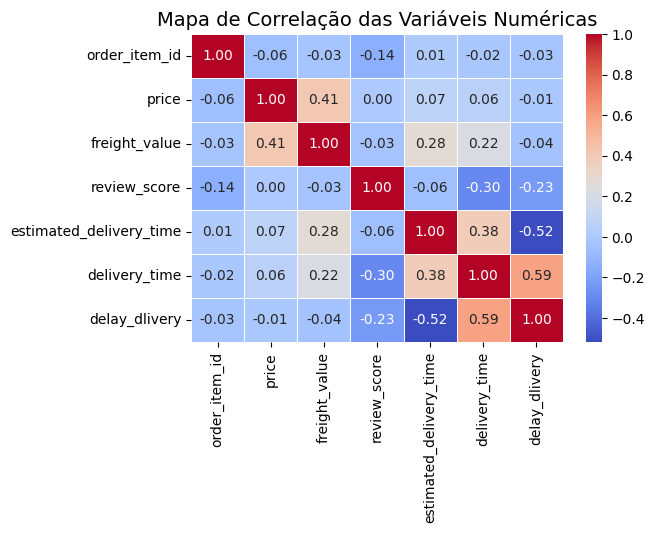

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supondo que seu dataframe final seja df
df_numerico = df.select_dtypes(include=['int64', 'float64'])

corr = df_numerico.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Correlação das Variáveis Numéricas', fontsize=14)
plt.show()

In [12]:
# Criar data de referência (última compra registrada)
ref_date = df['order_date'].max()

# Agregar por cliente
df_customers = df.groupby('customer_unique_id').agg(
    order_count=('order_id', 'count'),
    total_spent=('price', 'sum'),
    avg_order_value=('price', 'mean'),
    avg_review_score=('review_score', 'mean'),
    last_order=('order_date', 'max'),
    customer_state=('customer_state', 'first'),
    delay_dlivery=('delay_dlivery', 'mean')
).reset_index()

# Calcular recência (dias desde última compra)
df_customers['recency_days'] = (ref_date - df_customers['last_order']).dt.days

# Remover data e verificar resultado
df_customers = df_customers.drop(columns=['last_order'])


#visualiza_df(df_customers)


In [13]:
df_customers = df_customers.dropna(subset=['delay_dlivery']).reset_index(drop=True)
visualiza_df(df_customers)

 Formato:
91,492 linhas e 8 colunas.
 Valores ausentes:
customer_unique_id    0
order_count           0
total_spent           0
avg_order_value       0
avg_review_score      0
customer_state        0
delay_dlivery         0
recency_days          0
dtype: int64
 Duplicatas: 
0
 Tipos de dados: 
customer_unique_id     object
order_count             int64
total_spent           float64
avg_order_value       float64
avg_review_score      float64
customer_state         object
delay_dlivery         float64
recency_days            int64
dtype: object
 Pré-visualização dos dados: 


,customer_unique_id,order_count,total_spent,avg_order_value,avg_review_score,customer_state,delay_dlivery,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,5.0,SP,-4.0,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,4.0,SP,-4.0,114
2,0000f46a3911fa3c0805444483337064,1,69.00,69.00,3.0,SC,-2.0,536
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,4.0,PA,-11.0,320
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,5.0,SP,-7.0,287
...,...,...,...,...,...,...,...,...
91487,fffcf5a5ff07b0908bd4e2dbc735a684,2,1570.00,785.00,5.0,PE,-27.0,446
91488,fffea47cd6d3cc0a88bd621562a9d061,1,64.89,64.89,4.0,BA,-2.0,261
91489,ffff371b4d645b6ecea244b27531430a,1,89.90,89.90,5.0,MT,-30.0,567
91490,ffff5962728ec6157033ef9805bacc48,1,115.00,115.00,5.0,ES,-14.0,118


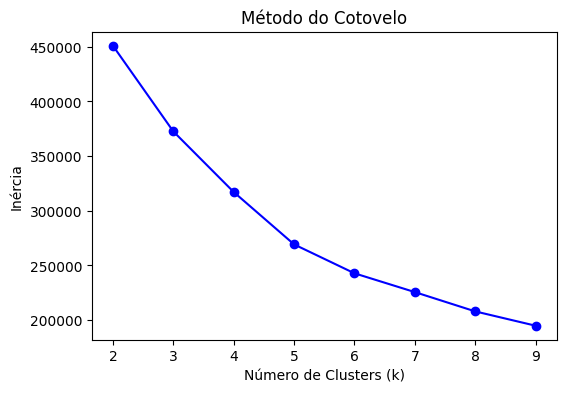

In [14]:
# Selecionar colunas numéricas relevantes
features = ['order_count', 'avg_order_value', 'total_spent', 'avg_review_score', 'recency_days', 'delay_dlivery']
X = df_customers[features]
SEED = 42
# Padronizar (média=0, desvio=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Soma das distâncias quadradas de cada ponto até o centro do seu cluster. Quanto menor, melhor o ajuste.
inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()



In [15]:
# Define 3 clusters para divisão
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_customers['cluster'] = kmeans.fit_predict(X_scaled)
# Médias das variáveis por cluster
cluster_summary = df_customers.groupby('cluster')[features].mean().round(2)
cluster_summary['count'] = df_customers['cluster'].value_counts().sort_index().values
cluster_summary


,order_count,avg_order_value,total_spent,avg_review_score,recency_days,delay_dlivery,count
cluster,,,,,,,
0,1.29,934.02,1058.20,4.18,244.57,-12.21,2672
1,1.48,102.87,139.15,1.83,231.99,-4.11,16220
2,1.15,101.07,112.66,4.67,236.70,-12.87,72600


###  Criação dos clusters

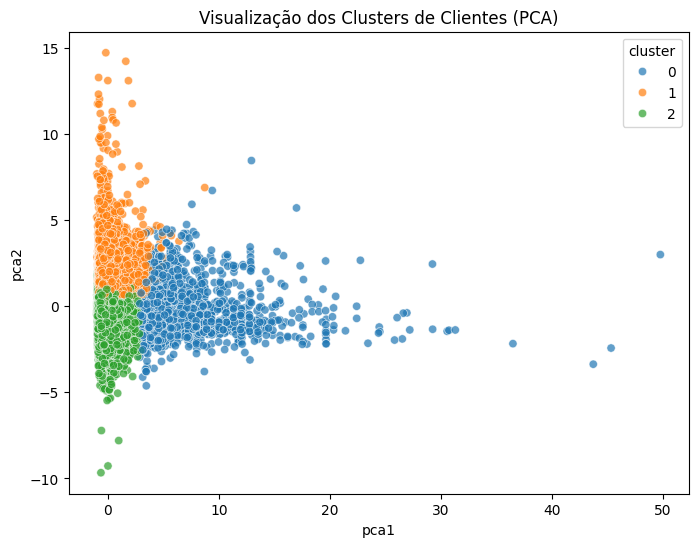

In [16]:
# Reduzir para 2 dimensões para visualizar clusters
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_customers['pca1'] = pca_result[:, 0]
df_customers['pca2'] = pca_result[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_customers,
    x='pca1', y='pca2',
    hue='cluster', palette='tab10', alpha=0.7
)
plt.title('Visualização dos Clusters de Clientes (PCA)')
plt.show()


In [17]:
from sklearn.metrics import silhouette_score
"""
Mede a distancia em relação ao centro do cluster
Quanto mais próximo de 1, melhor.
Aceitavel acima de 0.5
"""
for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df_numerico)
    score = silhouette_score(df_numerico, model.labels_)
    print(f'k={k}, silhouette={score:.3f}')

k=2, silhouette=0.867
k=3, silhouette=0.746
k=4, silhouette=0.613
k=5, silhouette=0.551
k=6, silhouette=0.527
k=7, silhouette=0.524
k=8, silhouette=0.463
k=9, silhouette=0.370


In [54]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# ADICIONE ISSO:
variance_explained = pca.explained_variance_ratio_
print(f"Variância explicada PC1: {variance_explained[0]:.2%}")
print(f"Variância explicada PC2: {variance_explained[1]:.2%}")
print(f"Variância total explicada: {sum(variance_explained):.2%}")

Variância explicada PC1: 32.00%
Variância explicada PC2: 21.52%
Variância total explicada: 53.51%


In [18]:
# Adicionar cluster ao DataFrame original
df_com_cluster = X.copy()
cluster_labels = kmeans.predict(X_scaled)
df_com_cluster['cluster'] = cluster_labels

# Média de cada variável por cluster
resumo = df_com_cluster.groupby('cluster').mean()

print("PERFIL MÉDIO DE CADA CLUSTER")
print("=" * 60)
print(resumo.round(1))

PERFIL MÉDIO DE CADA CLUSTER
         order_count  avg_order_value  total_spent  avg_review_score  \
cluster                                                                
0                1.3            934.0       1058.2               4.2   
1                1.5            102.9        139.1               1.8   
2                1.1            101.1        112.7               4.7   

         recency_days  delay_dlivery  
cluster                               
0               244.6          -12.2  
1               232.0           -4.1  
2               236.7          -12.9  


### Análise dos comentários

#### Criação do dataframe review com comentário e nota baixa

In [37]:
# Cria um DF apenas com comentário não em branco, e nota menor ou igual a 3
reviews_baixas = df.loc[(df['review_comment_message'].notna()) & (df['review_score'] <=3),['review_comment_message']]
# Verifica Duplicadas
reviews_baixas.duplicated(subset='review_comment_message').sum()
# Elimina os itens duplicados
reviews_baixas.drop_duplicates(subset='review_comment_message', inplace=True)
reviews_baixas.reset_index(drop=True, inplace=True)
#reviews_coment = reviews_coment[:100]
#Apenas para ter uma idéia dos reviews
#reviews_coment.to_csv('drive/MyDrive/Colab Notebooks/reviews_coment.csv', index=False)
#visualiza_df(reviews_baixas)

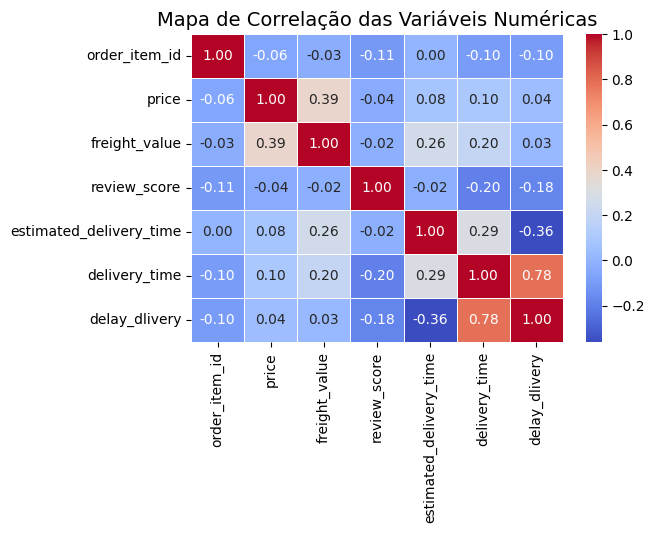

In [45]:
# df.loc[(df['review_comment_message'].notna()) & (df['review_score'] <=3),['review_comment_message']]
df_numerico_baixo = df.loc[(df['review_score'] <= 3)]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supondo que seu dataframe final seja df
df_numerico_baixo = df_numerico_baixo.select_dtypes(include=['int64', 'float64'])

corr = df_numerico_baixo.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Correlação das Variáveis Numéricas', fontsize=14)
plt.show()

#### Pré-processamento

In [21]:
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
#sns.set_style("whitegrid")
#plt.rcParams['figure.figsize'] = (12, 6)

# Dicionário de categorias com palavras-chave expandido
categorias = {
    'Entrega Atrasada': [
        'atrasado', 'atraso', 'demora', 'demorou', 'prazo', 'tempo',
        'chegou tarde', 'dias', 'semanas', 'mes', 'mês', 'meses', 'demorado',
        'entrega lenta', 'demorando', 'tardou', 'demorou muito',
        'chegou depois', 'passou do prazo', 'fora do prazo', 'esperando',
        'não chegou no prazo', 'muito tempo', 'tardio', 'aguardando',
        'ainda não chegou', 'aguardando entrega', 'quanto tempo',
        'há dias', 'há semanas', 'há meses', 'já faz tempo',
        'ainda esperando', 'demora demais', 'lentidão', 'lento',
        'mais de 30 dias', 'mais de 15 dias', 'mais de 20 dias',
        'ultrapassou', 'vencido', 'excedeu', 'estimativa errada',
        'deveria ter chegado', 'cadê', 'onde está', 'sumiu',
        'não chega nunca', 'eterna espera', 'demora eterna',
        'prazo estourado', 'não cumpriu prazo', 'fora do tempo',
        'entrega demorada', 'logística ruim', 'transportadora',
        'correios', 'sedex', 'pac', 'postagem', 'rastreio parado',
        'rastreamento', 'em trânsito', 'aguardando retirada',
        'objeto em trânsito', 'não saiu para entrega',
        # Sinônimos adicionados
        'tardança', 'retardado', 'retardo', 'dilação', 'delonga',
        'procrastinado', 'postergado', 'protelado', 'prorrogado',
        'estendido', 'alongado', 'moroso', 'vagaroso', 'lentíssimo',
        'arrastado', 'enrolado', 'engatinhando', 'não anda',
        'parado', 'estagnado', 'travado', 'emperrado', 'não sai do lugar',
        'não progride', 'não avança', 'sem previsão', 'indefinido',
        'atrasadíssimo', 'super atrasado', 'mega atrasado', 'muito atrasado',
        'extremamente atrasado', 'absurdamente atrasado', 'incrivelmente atrasado',
        'cronograma atrasado', 'cronograma furado', 'deadline perdido',
        'perdeu o prazo', 'estourou deadline', 'data perdida',
        'não cumpre', 'não entrega', 'não chega', 'demais',
        'tardando', 'demoradamente', 'vagarosamente', 'lerdamente'
    ],

    'Produto Defeituoso': [
        'defeito', 'quebrado', 'não funciona', 'estragado', 'danificado',
        'com problema', 'quebrou', 'parou de funcionar', 'não liga',
        'parou', 'funcionando mal', 'não presta', 'falha', 'travando',
        'com defeito', 'veio com defeito', 'não acende', 'não carrega',
        'não conecta', 'peças faltando', 'incompleto', 'rachado', 'vazando',
        'travou', 'bug', 'erro', 'desligando sozinho', 'reiniciando',
        'bateria ruim', 'não segura carga', 'descarrega rápido',
        'tela quebrada', 'tela rachada', 'arranhado', 'riscado',
        'botão não funciona', 'não responde', 'touch não funciona',
        'sem áudio', 'sem som', 'sem imagem', 'não sincroniza',
        'não reconhece', 'não detecta', 'falha de conexão',
        'desconecta', 'cai a conexão', 'não emparelha', 'bluetooth não funciona',
        'wifi não pega', 'não conecta wifi', 'sinal fraco',
        'queimou', 'queimado', 'cheiro de queimado', 'fazendo barulho',
        'barulho estranho', 'ruído', 'chiado', 'apitando',
        'não fecha', 'não abre', 'emperrado', 'travado', 'preso',
        'solto', 'folgado', 'bambo', 'mau contato', 'fio partido',
        'cabo partido', 'conector quebrado', 'entrada danificada',
        'não encaixa', 'frouxo', 'caindo', 'desmontando',
        'peça solta', 'peça quebrada', 'faltando parafuso',
        'veio incompleto', 'falta peça', 'componente faltando',
        'manual faltando', 'acessório faltando', 'garantia',
        'dentro da garantia', 'coberto pela garantia',
        # Sinônimos adicionados
        'avariado', 'avaria', 'defeituoso', 'com vício', 'viciado',
        'problemático', 'com anomalia', 'anômalo', 'irregular',
        'inutilizável', 'inoperante', 'inativo', 'morto', 'pifou',
        'pifado', 'fundiu', 'fundido', 'curto-circuito', 'curto',
        'desconfigurado', 'descalibrado', 'fora de calibração',
        'mal ajustado', 'desajustado', 'desregulado', 'desalinhado',
        'deteriorado', 'corrompido', 'corrupto', 'degradado',
        'ineficiente', 'ineficaz', 'imprestável', 'inapropriado',
        'falhando', 'falhado', 'malogrado', 'malfuncionando',
        'mau funcionamento', 'operação defeituosa', 'performance ruim',
        'desempenho ruim', 'não opera', 'não trabalha', 'não roda',
        'não executa', 'não processa', 'não ativa', 'não aciona',
        'trincado', 'fendido', 'fissura', 'fratura', 'fraturado',
        'esfarelando', 'desintegrando', 'despedaçado', 'esfacelado',
        'mutilado', 'truncado', 'comprometido', 'prejudicado',
        'lesionado', 'machucado', 'ferido', 'violado estruturalmente'
    ],

    'Qualidade Ruim': [
        'qualidade', 'ruim', 'péssimo', 'péssima', 'barato', 'frágil', 'horrível',
        'inferior', 'mal feito', 'pior', 'mal acabado', 'desbotado',
        'material ruim', 'produto fraco', 'não gostei', 'acabamento ruim',
        'mal costurado', 'mal montado', 'mal encaixado', 'desmanchando',
        'péssima qualidade', 'simples demais', 'dura pouco', 'descascando',
        'qualidade baixa', 'baixa qualidade', 'qualidade duvidosa',
        'parece usado', 'parece velho', 'parece falsificação', 'falsificado',
        'pirata', 'réplica', 'cópia', 'imitação', 'não é original',
        'chinês', 'china', 'produto chinês', 'genérico', 'xing ling',
        'acabamento tosco', 'acabamento grosseiro', 'mal acabamento',
        'fino demais', 'muito fino', 'fininho', 'transparente',
        'fragilizado', 'quebradiço', 'desmonta fácil', 'quebra fácil',
        'material fraco', 'plástico fraco', 'plástico fino',
        'parece brinquedo', 'parece de plástico', 'sem qualidade',
        'sem acabamento', 'grosseiro', 'tosco', 'mal feito mesmo',
        'feio', 'horroroso', 'medonho', 'decepcionante', 'decepção',
        'decepcionar', 'decepcionado', 'frustrante', 'frustração',
        'esperava mais', 'esperava melhor', 'não é bom', 'não é legal',
        'não recomendo', 'não comprem', 'não vale', 'não compensa',
        'arrependimento', 'me arrependi', 'arrependido', 'dinheiro jogado fora',
        'perdi dinheiro', 'prejuízo', 'joguei fora', 'lixo', 'porcaria',
        'unha', 'meia boca', 'mais ou menos', 'deixa a desejar',
        'poderia ser melhor', 'muito simples', 'simplório',
        'sem brilho', 'opaco', 'fosco demais', 'cor apagada',
        'sem acabamento', 'rebarbas', 'pontas soltas', 'fios soltos',
        'linha soltando', 'desfazendo', 'desgastando', 'desgaste rápido',
        'já estragou', 'estragou rápido', 'durou pouco', 'vida útil curta',
        # Sinônimos adicionados
        'inferior', 'inferiorizado', 'substandard', 'subnormal', 'subpar',
        'medíocre', 'mediocridade', 'ordinário', 'comum', 'vulgar',
        'rasteiro', 'baixo nível', 'baixo padrão', 'segunda linha',
        'terceira linha', 'categoria inferior', 'classe baixa',
        'vagabundo', 'vagabunda', 'porco', 'porca', 'mixaria',
        'mixuruca', 'fuleiro', 'fuleira', 'bisonho', 'brega',
        'cafona', 'ordinária', 'ordinário', 'xexelento', 'seboso',
        'mequetrepe', 'pé-rapado', 'chinfrím', 'vagabundagem',
        'sem categoria', 'sem classe', 'sem padrão', 'fora do padrão',
        'abaixo do padrão', 'não tem qualidade', 'zero qualidade',
        'qualidade inexistente', 'qualidade negativa', 'anti-qualidade',
        'sub-produto', 'produto de quinta', 'produto meia-boca',
        'sofisticação zero', 'requinte zero', 'primor zero',
        'capricho zero', 'esmero zero', 'zelo zero', 'cuidado zero',
        'desleixado', 'relaxado', 'porco', 'porcalhão', 'sujo',
        'malcuidado', 'maltratado', 'malconservado', 'malfeito'
    ],

    'Diferente da Descrição': [
        'diferente', 'não é', 'enganosa', 'propaganda', 'mentira',
        'não corresponde', 'enganação', 'foto', 'descrição', 'errada',
        'não veio igual', 'não é o mesmo', 'tamanho errado', 'cor errada',
        'modelo errado', 'formato diferente', 'outra coisa', 'produto trocado',
        'não condiz', 'diferente do site', 'nada a ver', 'parece outro', 'enganado',
        'diferente da foto', 'diferente da imagem', 'diferente do anúncio',
        'foto enganosa', 'imagem enganosa', 'propaganda enganosa',
        'descrição falsa', 'descrição errada', 'descrição incompleta',
        'não é como mostrado', 'não é igual', 'outro produto',
        'enviaram errado', 'produto errado', 'item errado',
        'veio outro', 'veio diferente', 'trocaram', 'substituíram',
        'não era isso', 'não era esse', 'não era o que pedi',
        'não comprei isso', 'não pedi isso', 'erro no pedido',
        'tamanho não confere', 'tamanho diferente', 'menor que o esperado',
        'maior que o esperado', 'muito pequeno', 'muito grande',
        'pequeno demais', 'grande demais', 'dimensões erradas',
        'medidas erradas', 'especificações erradas', 'características erradas',
        'cor diferente', 'tonalidade diferente', 'tonalidade errada',
        'mais claro', 'mais escuro', 'outra cor', 'cor não confere',
        'modelo diferente', 'versão diferente', 'tipo diferente',
        'marca diferente', 'fabricante diferente', 'não é da marca',
        'falsificaram', 'tentativa de fraude', 'fraude', 'golpe',
        'me enganaram', 'fui enganado', 'mentiroso', 'mentira descarada',
        'iludido', 'ludibriar', 'ludibriado', 'enrolação',
        'não bate', 'não corresponde à foto', 'totalmente diferente',
        'completamente diferente', 'nada parecido', 'expectativa x realidade',
        'esperava outra coisa', 'não era o que imaginava',
        'especificações não batem', 'informações incorretas',
        # Sinônimos adicionados
        'discrepante', 'discrepância', 'divergente', 'divergência',
        'destoante', 'incongruente', 'incompatível', 'inconsistente',
        'desconforme', 'não conforme', 'não compatível', 'desigual',
        'dissimilar', 'distinto', 'dispar', 'disparidade',
        'alterado', 'modificado', 'mudado', 'variado', 'variante',
        'adulterado', 'falsificado', 'forjado', 'contrafação',
        'contrafeito', 'imitado', 'simulado', 'fingido', 'falso',
        'enganador', 'enganoso', 'ilusório', 'falacioso', 'falaciosa',
        'trapaceiro', 'trapaceado', 'logro', 'logrado', 'embuste',
        'embusteiro', 'charlatanismo', 'charlatão', 'vigarice',
        'vigarista', 'calote', 'caloteiro', 'conto do vigário',
        'propaganda falsa', 'marketing enganoso', 'marketing falso',
        'publicidade enganosa', 'publicidade falsa', 'anúncio falso',
        'informação falsa', 'dado incorreto', 'dado errado',
        'especificação falsa', 'característica falsa', 'atributo falso',
        'não corresponde ao anunciado', 'não é o anunciado',
        'não é o prometido', 'promessa falsa', 'promessa não cumprida',
        'expectativa frustrada', 'ilusão', 'decepção visual',
        'realidade diferente', 'na prática é outro', 'ao vivo é outro'
    ],

    'Embalagem Danificada': [
        'embalagem', 'caixa', 'lacre', 'amassado', 'rasgada',
        'aberta', 'violada', 'pacote', 'mal embalada', 'amassada',
        'estragada', 'rasgo', 'mal protegida', 'sem proteção',
        'chegou aberto', 'avariada', 'molhada', 'faltando selo',
        'mal acondicionada', 'plástico rasgado', 'plástico furado',
        'caixa amassada', 'caixa rasgada', 'caixa aberta',
        'caixa violada', 'caixa danificada', 'caixa destruída',
        'caixa toda amassada', 'embalagem destruída', 'embalagem aberta',
        'embalagem violada', 'embalagem rasgada', 'embalagem furada',
        'lacre quebrado', 'lacre rompido', 'sem lacre', 'lacre violado',
        'selo quebrado', 'selo rompido', 'sem selo', 'selo violado',
        'chegou aberto', 'já veio aberto', 'veio aberto', 'veio violado',
        'proteção inadequada', 'sem proteção adequada', 'mal embalado',
        'embalagem fraca', 'embalagem inadequada', 'mal protegido',
        'sem plástico bolha', 'sem bubble wrap', 'sem isopor',
        'jogado na caixa', 'sem cuidado', 'mal acondicionado',
        'molhado', 'úmido', 'água', 'chuva', 'chegou molhado',
        'embalagem molhada', 'caixa molhada', 'produto molhado',
        'sujo', 'sujeira', 'pó', 'poeira', 'manchado',
        'machucado', 'batido', 'arranhão na caixa', 'marca na caixa',
        'parece usado', 'parece que já abriram', 'já foi aberto',
        'reembalado', 'usado e reembalado', 'refurbished não informado',
        'segunda mão', 'parece segunda mão', 'caixa original violada',
        'fita crepe', 'mal fechado', 'fechamento ruim',
        'empacotamento ruim', 'empacotamento inadequado',
        # Sinônimos adicionados
        'avariada', 'deteriorada', 'degradada', 'danificada',
        'lesada', 'lesionada', 'comprometida', 'prejudicada',
        'estropiada', 'mutilada', 'deformada', 'desfigurada',
        'amachucada', 'contundida', 'machucada', 'ferida',
        'dilacerada', 'estraçalhada', 'esfacelada', 'despedaçada',
        'partida', 'fendida', 'rachada', 'trincada', 'fissura',
        'perfurada', 'furada', 'vazada', 'com furo', 'com buraco',
        'rompida', 'rasgada', 'lacerada', 'cortada', 'picada',
        'esgarçada', 'esfiapada', 'desfiada', 'puída',
        'gasto', 'usado', 'desgastado', 'surrado', 'velho',
        'encharcada', 'ensopada', 'embebida', 'umedecida', 'úmida',
        'saturada', 'pingando', 'gotejando', 'vazando água',
        'mofada', 'mofo', 'bolor', 'bolorenta', 'fungos',
        'encardida', 'imunda', 'porca', 'sebosa', 'nojenta',
        'contaminada', 'insalubre', 'anti-higiênica', 'suja',
        'empacotamento desleixado', 'embalagem relaxada', 'embalagem porca',
        'acondicionamento péssimo', 'acondicionamento inadequado',
        'manuseio incorreto', 'mal manuseada', 'maltratada',
        'sem cuidado no transporte', 'jogada', 'arremessada',
        'caída', 'derrubada', 'batida', 'impactada', 'esmagada'
    ],

    'Atendimento Ruim': [
        'atendimento', 'suporte', 'resposta', 'contato', 'vendedor',
        'não responde', 'mal atendido', 'ignorado', 'atendem', 'respondem',
        'demoram a responder', 'sem retorno', 'sem resposta',
        'não resolvem', 'suporte ruim', 'tratamento ruim', 'má vontade',
        'falta de atenção', 'descaso', 'grosseiro', 'mal educado',
        'vendedor sumiu', 'sem ajuda', 'atendimento péssimo',
        'atendimento horrível', 'péssimo atendimento', 'horrível atendimento',
        'não atendem', 'ninguém responde', 'ninguém atende',
        'chat não funciona', 'telefone não atende', 'telefone ocupado',
        'não consegui contato', 'impossível contato', 'difícil contato',
        'não dão suporte', 'sem suporte', 'suporte inexistente',
        'suporte péssimo', 'suporte horrível', 'ignoram mensagens',
        'ignoram emails', 'ignoram reclamação', 'não respondem email',
        'não respondem mensagem', 'não respondem whatsapp',
        'demora na resposta', 'demoram dias', 'demoram semanas',
        'resposta automática', 'robô', 'bot', 'resposta pronta',
        'resposta padrão', 'não resolvem nada', 'não solucionam',
        'não ajudam', 'não auxiliam', 'jogam a culpa',
        'empurram problema', 'não assumem responsabilidade',
        'enrolam', 'enrolação', 'enganação', 'só enrolam',
        'rude', 'grosseria', 'grosseiro', 'educação zero',
        'falta de educação', 'mal educação', 'arrogante', 'prepotente',
        'debochado', 'irônico', 'sarcástico', 'zombando',
        'tratam mal', 'desrespeitoso', 'desrespeito', 'humilhante',
        'sac ruim', 'sac péssimo', 'sac não funciona',
        'ombudsman', 'ouvidoria', 'procon', 'reclame aqui',
        'vou no procon', 'vou reclamar', 'acionarei judicialmente',
        'processarei', 'advogado', 'justiça', 'judicial',
        'direito do consumidor', 'código de defesa',
        'vendedor mentiroso', 'vendedor enganador', 'vendedor sumiu',
        'vendedor não responde mais', 'após venda', 'pós-venda ruim',
        'pós-venda inexistente', 'não dão assistência',
        # Sinônimos adicionados
        'indiferente', 'indiferença', 'desinteressado', 'desinteresse',
        'negligente', 'negligência', 'negligenciado', 'relegado',
        'desprezado', 'desprezo', 'desdenhado', 'desdém',
        'menosprezado', 'menosprezo', 'desatenção', 'desatento',
        'incomunicável', 'inacessível', 'inalcançável', 'intocável',
        'indisponível', 'ausente', 'omisso', 'omissão', 'omitem',
        'negligenciam', 'abandonado', 'desassistido', 'desamparado',
        'indelicado', 'descortês', 'incivil', 'rústico', 'bruto',
        'ríspido', 'áspero', 'agressivo', 'hostil', 'antipático',
        'insolente', 'impertinente', 'petulante', 'atrevido',
        'desaforado', 'desrespeitoso', 'irreverente', 'irresponsável',
        'incompetente', 'incompetência', 'ineficiente', 'ineficaz',
        'incapaz', 'despreparado', 'inapto', 'inadequado',
        'amadorismo', 'amador', 'não profissional', 'pouco profissional',
        'serviço porco', 'serviço vagabundo', 'serviço relaxado',
        'comunicação falha', 'comunicação ruim', 'não comunicam',
        'falta comunicação', 'zero comunicação', 'comunicação zero',
        'sem feedback', 'sem retorno', 'sem follow-up', 'sem acompanhamento',
        'sem posicionamento', 'sem explicação', 'sem satisfação',
        'não dão satisfação', 'não se pronunciam', 'silêncio',
        'ghosting', 'sumiram', 'desapareceram', 'evaporaram',
        'ríspido', 'mal-humorado', 'emburrado', 'carrancudo',
        'azedo', 'rabugento', 'irritadiço', 'irritado', 'estressado'
    ],

    'Problema na Entrega': [
        'não chegou', 'sumiu', 'extraviado', 'não recebi', 'entrega errada',
        'entregaram outro', 'entregaram errado', 'perdido', 'extravio',
        'faltando item', 'não veio tudo', 'faltou', 'não recebi o produto',
        'entrega incompleta', 'chegou só parte', 'entrega incorreta',
        'ainda não chegou', 'não foi entregue', 'entrega não realizada',
        'tentativa de entrega', 'ausente na entrega', 'não estava em casa',
        'não avisaram', 'sem aviso', 'não tocaram campainha',
        'não bateram', 'deixaram aviso', 'carteiro não veio',
        'carteiro não tocou', 'entregador não tocou', 'entregador sumiu',
        'rastreio parado', 'rastreamento parado', 'rastreio não atualiza',
        'objeto aguardando retirada', 'retirar nos correios',
        'agência dos correios', 'agência postal', 'unidade de distribuição',
        'endereço errado', 'endereço incorreto', 'cep errado',
        'número errado', 'complemento errado', 'destinatário errado',
        'nome errado', 'entregaram no vizinho', 'entregaram em outro lugar',
        'entregaram na portaria', 'portaria não avisou', 'porteiro não entregou',
        'objeto roubado', 'roubo', 'furto', 'sumiço', 'desapareceu',
        'perderam meu pedido', 'transportadora perdeu',
        'correios perdeu', 'extraviaram', 'extraviou',
        'avariado no transporte', 'danificado no transporte',
        'quebrou no transporte', 'amassou no transporte',
        'objeto avariado', 'nota fiscal errada', 'nota fiscal de outro',
        'nota fiscal incorreta', 'produto de outro pedido',
        'veio produto de outra pessoa', 'trocaram os pedidos',
        'confusão na entrega', 'erro de logística', 'erro da transportadora',
        'devolveram ao remetente', 'voltou para o remetente',
        'não tentaram entregar', 'marcaram como entregue',
        'diz que entregaram mas não entregaram', 'entrega fantasma',
        'entrega fake', 'falsa entrega', 'assinatura falsa',
        'não fui eu que recebi', 'não autorizei recebimento',
        'deixaram no chão', 'jogaram no portão', 'entrega inadequada',
        # Sinônimos adicionados
        'não recebido', 'não chegado', 'não entregue', 'não recepcionado',
        'desaparecido', 'evaporado', 'volatilizado', 'esfumado',
        'perdido no caminho', 'perdido no trajeto', 'perdido na rota',
        'em local desconhecido', 'paradeiro desconhecido', 'localização desconhecida',
        'subtraído', 'surrupiado', 'furtado', 'roubado', 'levado',
        'interceptado', 'desviado', 'redirecionado', 'mal encaminhado',
        'entrega frustrada', 'entrega malsucedida', 'entrega fracassada',
        'falha na entrega', 'falha logística', 'falha operacional',
        'erro operacional', 'erro de procedimento', 'procedimento errado',
        'protocolo errado', 'processo errado', 'falha de processo',
        'destinação errada', 'destino errado', 'local errado',
        'lugar errado', 'endereçamento errado', 'roteiro errado',
        'rota errada', 'trajeto errado', 'percurso errado',
        'ordem de entrega errada', 'sequência errada', 'prioridade errada',
        'distribuição errada', 'triagem errada', 'separação errada',
        'sortimento errado', 'seleção errada', 'picking errado',
        'expedição errada', 'despacho errado', 'remessa errada',
        'envio errado', 'remessa trocada', 'expedição trocada',
        'produto trocado', 'item trocado', 'mercadoria trocada',
        'confusão de pedidos', 'mistura de pedidos', 'pedidos misturados',
        'logística falha', 'logística defeituosa', 'logística ruim',
        'transporte inadequado', 'transporte falho', 'transportadora falha',
        'operação logística ruim', 'gestão logística ruim',
        'rastreamento incorreto', 'tracking errado', 'código de rastreio errado',
        'status errado', 'informação errada', 'dado de rastreio errado',
        'atualização errada', 'status falso', 'informação falsa',
        'não localizável', 'impossível rastrear', 'sem rastreabilidade',
        'tentativa falsa', 'tentativa não realizada', 'não tentaram',
        'negligência na entrega', 'descuido na entrega', 'desleixo na entrega'
    ],

    'Preço / Custo-benefício': [
        'caro', 'muito caro', 'não vale o preço', 'caríssimo', 'preço alto',
        'valor alto', 'não compensa', 'podia ser mais barato',
        'pouca qualidade pelo preço', 'não vale a pena', 'custo-benefício ruim',
        'esperava mais pelo preço', 'valor abusivo', 'produto simples e caro',
        'custo benefício', 'custo x benefício', 'relação custo benefício',
        'pelo preço que paguei', 'pelo valor', 'por esse preço',
        'preço salgado', 'preço absurdo', 'preço exagerado',
        'preço exorbitante', 'superfaturado', 'cobram muito',
        'cobram caro', 'muito caro pelo que é', 'caro demais',
        'excessivamente caro', 'valor não condiz', 'valor inadequado',
        'valor injusto', 'injusto pelo preço', 'pagamento injusto',
        'não justifica o preço', 'preço não se justifica',
        'qualidade não justifica', 'não vale esse valor',
        'não vale tanto', 'achei caro', 'achei muito caro',
        'esperava mais qualidade', 'esperava melhor qualidade',
        'pelo que paguei esperava mais', 'decepção pelo preço',
        'fui no mais barato', 'barato sai caro', 'saiu caro',
        'vi mais barato', 'mais barato em outro lugar',
        'encontrei mais barato', 'no concorrente é mais barato',
        'na loja física é mais barato', 'preço desatualizado',
        'aumentou o preço', 'preço mudou', 'não é o preço anunciado',
        'cobraram mais caro', 'cobraram a mais', 'valor diferente',
        'frete caro', 'frete muito caro', 'frete abusivo',
        'frete não vale a pena', 'frete mais caro que produto',
        'pagaria mais barato', 'preferível comprar em outro lugar',
        'não compraria novamente', 'não compro mais', 'primeira e última vez',
        'desperdício de dinheiro', 'joguei dinheiro fora',
        'perdi meu dinheiro', 'dinheiro perdido', 'prejuízo financeiro',
        'não recomendo pela price', 'não recomendo pelo valor',
        'qualidade inferior ao preço', 'preço não compatível',
        # Sinônimos adicionados
        'dispendioso', 'oneroso', 'custoso', 'custa caro', 'alto custo',
        'elevado', 'inflacionado', 'majorado', 'aumentado', 'sobrepreço',
        'sobretaxa', 'sobrecarga', 'sobrecusto', 'excesso de preço',
        'preço nas alturas', 'preço nas nuvens', 'preço estratosférico',
        'preço astronômico', 'preço proibitivo', 'inacessível', 'proibitivo',
        'fora do orçamento', 'fora do alcance', 'inviável', 'impraticável',
        'luxuoso demais', 'premium demais', 'sofisticado demais para o que é',
        'preço desproporcional', 'desproporção', 'desproporcional',
        'incompatível com qualidade', 'qualidade incompatível',
        'preço incompatível', 'valor desproporcional', 'desbalanceado',
        'desequilibrado', 'assimetria de valor', 'relação ruim',
        'proporção ruim', 'razão ruim', 'equação ruim', 'conta não fecha',
        'matemática não fecha', 'não faz sentido financeiro',
        'economicamente inviável', 'financeiramente ruim', 'mau negócio',
        'negócio ruim', 'péssimo negócio', 'transação ruim',
        'compra ruim', 'aquisição ruim', 'investimento ruim',
        'mau investimento', 'péssimo investimento', 'investimento perdido',
        'capital perdido', 'recursos desperdiçados', 'dinheiro mal gasto',
        'gasto desnecessário', 'despesa excessiva', 'custo excessivo',
        'desembolso alto', 'pagamento exorbitante', 'quantia absurda',
        'soma absurda', 'montante absurdo', 'valor excessivo',
        'cobrança abusiva', 'cobrança excessiva', 'cobrança indevida',
        'tarifa abusiva', 'taxa abusiva', 'encargo abusivo',
        'exploração', 'exploratório', 'extorsivo', 'extorsão',
        'roubo', 'assalto', 'estelionato', 'é um roubo',
        'preço de roubo', 'roubada', 'furada', 'cilada',
        'pegadinha', 'armadilha financeira', 'armadilha de preço',
        'comparativamente caro', 'relativamente caro', 'proporcionalmente caro',
        'desvalorizado', 'sem valor agregado', 'sem valor adicional',
        'valor agregado zero', 'adicional inexistente', 'plus inexistente',
        'diferencial inexistente', 'vantagem inexistente', 'benefício inexistente',
        'retorno baixo', 'retorno ruim', 'roi baixo', 'roi negativo',
        'payback ruim', 'amortização ruim', 'recuperação impossível',
        'irrecuperável', 'perda total', 'perda completa', 'perda integral'
    ]
}





#### Modelagem

In [22]:
def normalizar_texto(t):
  t = t.lower()
  t = re.sub(r'[^a-zà-ú0-9\s]', '', t)  # remove pontuação
  t = re.sub(r'\s+', ' ', t).strip()
  return t
reviews_baixas['review_comment_message'] = reviews_baixas['review_comment_message'].apply(normalizar_texto)

def classificar_review(texto):
    """
    Classifica o review baseado em palavras-chave
    Retorna a categoria com maior score
    """

    #Normalização do texto
    texto_lower = str(texto).lower()
    scores = {}

    for categoria, palavras in categorias.items():
        # Conta quantas palavras-chave aparecem no texto
        score = sum(palavra in texto_lower for palavra in palavras)
        scores[categoria] = score

    # Retorna a categoria com maior score, ou 'Outros' se nenhuma palavra foi encontrada
    if max(scores.values()) > 0:
        return max(scores, key=scores.get)
    return 'Outros'

# Aplicar classificação
reviews_baixas['motivo'] = reviews_baixas['review_comment_message'].apply(classificar_review)
# Gerar DataFrame de distribuição
motivos_df = (
    reviews_baixas['motivo']
    .value_counts()
    .rename_axis('Motivo')
    .reset_index(name='Quantidade')
)

#### Visualização da modelagem

In [53]:
# Resultados da classificação
motivos_df['% share'] = (motivos_df['Quantidade'] / motivos_df['Quantidade'].sum())*100
motivos_df = motivos_df.sort_values(by='Quantidade', ascending=True)
motivos_df

,Motivo,Quantidade,% share
8,Preço / Custo-benefício,68,0.564925
7,Embalagem Danificada,406,3.372933
6,Atendimento Ruim,505,4.195398
5,Produto Defeituoso,760,6.313866
4,Diferente da Descrição,925,7.684639
3,Qualidade Ruim,1184,9.836338
2,Problema na Entrega,1335,11.090803
1,Entrega Atrasada,3295,27.373930
0,Outros,3559,29.567168


In [51]:
cores = ['coral' if i in [7, 6, 5] else 'steelblue'
         for i in range(len(motivos_df))]

graf_motivos_review_baixo = px.bar(
    motivos_df,
    y='Motivo',
    x='Quantidade',
    title='Motivos das avaliações ruins',
    text='Quantidade',
    width=600,
    height=400,
    hover_data={'% share': ':.1f'}
)

# Aplicar cores manualmente
graf_motivos_review_baixo.update_traces(marker_color=cores)

graf_motivos_review_baixo.show()

ValueError: Value of 'hover_data_0' is not the name of a column in 'data_frame'. Expected one of ['Motivo', 'Quantidade'] but received: % share

In [52]:
Qtd_total = df['review_comment_message'].notna().sum()
qtd_analizada = motivos_df['Quantidade'].sum()
percentual = (qtd_analizada / Qtd_total)*1

print(f'Total de comentários: {Qtd_total:,.0f}')
print(f'Total de comentários analizados: {qtd_analizada:,.0f} ({percentual:.1%})')


Total de comentários: 46,434
Total de comentários analizados: 12,037 (25.9%)


In [26]:
filtro_outros = reviews_baixas[reviews_baixas['motivo'] == 'Outros']
filtro_outros.duplicated(subset='review_comment_message').sum()
filtro_outros.drop_duplicates(subset='review_comment_message', inplace=True)
filtro_outros.reset_index(drop=True, inplace=True)
filtro_outros.head(20)

,review_comment_message,motivo
0,a cuba veio quebrada como efetuo barroca,Outros
1,pensei que a cinta seria mais larga é muito es...,Outros
2,muito bom o produto e preço cobrado,Outros
3,tudo em ordem,Outros
4,os outros produtos a loja ofereceu mas não cum...,Outros
5,só foi entregue 1 dos 3 produtos q comprei,Outros
6,nao gostei do produto pois veio com detalhes n...,Outros
7,minha opinião é que se comprei o produto ele t...,Outros
8,um pézinho maior que o outros,Outros
9,não interessa se opera market place a compra f...,Outros


### Total de clientes e vendedores

In [49]:
Total_vendedores = df['seller_id'].nunique()
print(f'Total de vendedores: {Total_vendedores:,.0f}')

Total_clientes = df['customer_unique_id'].nunique()
print(f'Total de clientes: {Total_clientes:,.0f}')

Qtd_vendas = df['order_id'].nunique()
print(f'Quantidade de vendas: {Qtd_vendas:,.0f}')

venda_total = df['price'].sum()
print(f'Valor total vendido: R$ {venda_total:,.2f}')

Ticket_Medio = venda_total / Qtd_vendas
print(f'Ticket médio: R$ {Ticket_Medio:,.2f}')

Media_avaliações = df['review_score'].mean()
print(f'Média de avaliações: {Media_avaliações:,.2f}')

Prazo_medio = df['delivery_time'].mean()
print(f'Prazo médio de entrega: {Prazo_medio:,.0f} dias')

Percentual_atraso = ((df['delay_dlivery'] > 0).sum() / Qtd_vendas)*100
print(f'Percentual de pedidos com atraso: {Percentual_atraso:,.2f}%')

Total de vendedores: 2,909
Total de clientes: 91,492
Quantidade de vendas: 94,499
Valor total vendido: R$ 13,263,381.53
Ticket médio: R$ 140.35
Média de avaliações: 4.08
Prazo médio de entrega: 12 dias
Percentual de pedidos com atraso: 8.48%


### Evolução das vendas

In [ ]:
Vendas_por_mes = df.groupby(df['order_date'].dt.month)['price'].sum().reset_index()
Vendas_por_mes['order_date'] = Vendas_por_mes['order_date'].replace({1:'Janeiro',2:'Fevereiro',3:'Março',4:'Abril',5:'Maio',6:'Junho',7:'Julho',8:'Agosto',9:'Setembro',10:'Outubro',11:'Novembro',12:'Dezembro'})
graf_vendas_mes = px.bar(Vendas_por_mes, x='order_date', y='price', title='Vendas por mês', text='price')
graf_vendas_mes.update_traces(texttemplate='R$ %{text:.3s}', textposition='inside')
graf_vendas_mes.update_layout(xaxis_title='Mês', yaxis_title='Valor Total')
graf_vendas_mes.update_xaxes(tickmode='array',tickvals=Vendas_por_mes['order_date'],ticktext=Vendas_por_mes['order_date'])
graf_vendas_mes.show()

In [ ]:
Evolução_vendas = df.groupby(df['order_date'].dt.date)['price'].sum().reset_index()
graf_vendas_dia = px.line(Evolução_vendas, x='order_date', y='price', title='Evolução das Vendas', text='price')
graf_vendas_dia.update_traces(mode='lines+markers', marker=dict(size=4), line=dict(width=2))
Evolução_vendas['media_7d'] = Evolução_vendas['price'].rolling(window=7).mean()
graf_vendas_dia.add_scatter(
    x=Evolução_vendas['order_date'],
    y=Evolução_vendas['media_7d'],
    mode='lines',
    name='Média móvel (7 dias)',
    line=dict(color='orange', width=3)
)

# 3. Layout e estilo visual
graf_vendas_dia.update_layout(
    yaxis_title='Valor (R$)',
    xaxis_title='Data do pedido',
    title_x=0.5,
    template='plotly_white',
    plot_bgcolor='rgba(0,0,0,0)',
    #paper_bgcolor='rgba(0,0,0,0)',
    font=dict(size=13),
)

# 4. Formatar eixo Y com separador de milhar
graf_vendas_dia.update_yaxes(tickprefix='R$', separatethousands=True)

graf_vendas_dia.show()

### Distribuição de clientes por estado

In [ ]:

# Carregar GeoJSON dos estados do Brasil
url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
brazil_geojson = requests.get(url).json()

# Agregar valor total dos pedidos por estado
state_values = df_customers.groupby('customer_state').size().reset_index(name='num_clientes')

# Mapear UF para nome completo dos estados
uf_to_state = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas",
    "BA": "Bahia", "CE": "Ceará", "DF": "Distrito Federal", "ES": "Espírito Santo",
    "GO": "Goiás", "MA": "Maranhão", "MT": "Mato Grosso", "MS": "Mato Grosso do Sul",
    "MG": "Minas Gerais", "PA": "Pará", "PB": "Paraíba", "PR": "Paraná",
    "PE": "Pernambuco", "PI": "Piauí", "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul", "RO": "Rondônia", "RR": "Roraima", "SC": "Santa Catarina",
    "SP": "São Paulo", "SE": "Sergipe", "TO": "Tocantins"
}

state_values['state_name'] = state_values['customer_state'].map(uf_to_state)

# Criar mapa coroplético pelo valor total dos pedidos
fig = px.choropleth_mapbox(
    state_values,
    geojson=brazil_geojson,
    locations='state_name',
    featureidkey='properties.name',
    color='num_clientes',
    color_continuous_scale='Viridis',
    mapbox_style="carto-positron",
    zoom=3,
    width=800,
    height=600,
    center = {"lat": -14.2350, "lon": -51.9253},
    opacity=0.7,
    labels={'total_pedidos':'Valor Total dos Pedidos'},
    title="Distribuição da quantidade de clientes por Estado"
)

fig.show()

### Top 10 categoria de produtos

In [ ]:
Categoria_produtos = df.groupby(['product_category_name'])['price'].sum().sort_values(ascending=False).reset_index().head(10)

graf_10_categorias = px.bar(Categoria_produtos, x='product_category_name', y='price', title='Top 10 Categorias | Vendas', text='price')
graf_10_categorias.update_traces(texttemplate='R$ %{text:.3s}', textposition='inside')
graf_10_categorias.update_layout(xaxis_title='Categoria', yaxis_title='Valor Total')
graf_10_categorias.show()

### Reviews por categoria

In [ ]:
# Agrupamento e ordenação
Review_categoria = (
    df.groupby(['product_category_name'])
    .aggregate({'review_score':'mean','order_id':'count'})
    .reset_index()
    .sort_values(by='review_score', ascending=True)
    .head(10)
)

# Criação do gráfico
fig = go.Figure()

# Barras (quantidade de reviews)
fig.add_trace(
    go.Bar(
        x=Review_categoria['product_category_name'],
        y=Review_categoria['order_id'],
        name='Qtde de Reviews',
        text=Review_categoria['order_id'],
        textposition='outside',
    )
)

# Linha (review score médio)
fig.add_trace(
    go.Scatter(
        x=Review_categoria['product_category_name'],
        y=Review_categoria['review_score'],
        name='Review Score Médio',
        mode='lines+markers',
        text=Review_categoria['review_score'],
        yaxis='y2',
        line=dict(color='orange', width=3)
    )
)

# Layout
fig.update_layout(
    width=1200,
    height=400,
    title='Categorias com piores reviews',
    xaxis_title='Categoria de Produto',
    yaxis_title='Quantidade de Reviews',
    yaxis2=dict(
        title='Review Score Médio',
        overlaying='y',
        side='right'
    ),
    legend=dict(
        title='Legenda',
        orientation='v',     # 'v' = vertical (padrão), 'h' = horizontal
        yanchor='bottom',    # ancora vertical da legenda
        y=1.1,              # posição vertical (1.0 = topo do gráfico)
        xanchor='right',     # ancora horizontal da legenda
        x=1,                 # posição horizontal (1.0 = lado direito do gráfico)
        bgcolor='rgba(255,255,255,0.7)',  # fundo semitransparente
        bordercolor='black',
        borderwidth=1
    ),
    template='plotly_white'
)

fig.show()


### Distribuição da frequencia das notas

In [ ]:
Dist_Reviews = (df.groupby('review_score').agg(count=('review_score', 'count')).reset_index().sort_values(by='review_score', ascending=True))
graf_Dist_Reviews = px.histogram(df, x='review_score', title='Distribuição da frequencia das notas', nbins=5, text_auto=',.0f', width=600, height=400)
graf_Dist_Reviews.update_layout(xaxis_title='Nota', yaxis_title='Quantidade de pedidos')
graf_Dist_Reviews.show()

### Distribuição dos tipos de pagamento


In [ ]:
Dist_Reviews = (df.groupby('payment_type').agg(count=('payment_type', 'count')).reset_index().sort_values(by='payment_type', ascending=True))
graf_Dist_Reviews = px.histogram(df, x='payment_type', title='Distribuição por tipo de pagamento', nbins=4, text_auto=',.0f', width=600, height=400)
graf_Dist_Reviews.update_layout(xaxis_title='Tipo de pagamento', yaxis_title='Quantidade de pedidos')
graf_Dist_Reviews.show()

### Distribuição do tempo de entrega

In [50]:
# Limites pelos percentis (2.5% e 97.5%)
q_low = df['delivery_time'].quantile(0.025)
q_high = df['delivery_time'].quantile(0.975)

# Filtrar apenas o intervalo principal
df_main = df[(df['delivery_time'] >= q_low) & (df['delivery_time'] <= q_high)]

# Gráfico
graf_main = px.histogram(
    df_main,
    x='delivery_time',
    title='Distribuição principal do tempo de entrega (sem outliers)',
    nbins=30,
    text_auto=',.0f',
    width=700,
    height=400
)

# Personalizar eixos
graf_main.update_layout(
    xaxis_title='Tempo de entrega (dias)',
    yaxis_title='Quantidade de pedidos',
    xaxis=dict(
        tickmode='linear',       # força ticks numéricos contínuos
        dtick=2,                 # define espaçamento (ex: 1 dia entre ticks)
        tickangle=0,             # rotação do texto (0 = horizontal)
        showticklabels=True,     # garante exibição das legendas
        tickfont=dict(size=10)   # tamanho da fonte dos ticks
    )
)

graf_main.show()



In [ ]:
visualiza_df(df)

## Implantação

In [ ]:
"""
Os clusters obtidos podem ser usados para segmentar clientes e ajustar campanhas.
O modelo foi salvo com:
"""
import joblib
joblib.dump(kmeans, "modelo_kmeans_olist.pkl")
